# SAE-XCrash — NB05: Cross-Dataset Transfer (US → UK STATS19)
**Work Package WP5** | Target: *Accident Analysis & Prevention* (Q1, Elsevier)

---
### Steps
| # | Description | Paper output |
|---|-------------|-------------|
| 1 | Environment setup & Drive mount | — |
| 2 | Load US model, common features, STATS19 splits | FEAT_COMMON (22 features) |
| 3 | Zero-shot transfer: US XGBoost → STATS19 test | Table 6 row 1 |
| 4 | STATS19 recalibration (fit isotonic on S19 val) | Table 6 row 2 |
| 5 | STATS19 full retrain: XGBoost + LightGBM | Table 6 rows 3–4 |
| 6 | Calibration on STATS19 retrained models | Table 6 rows 3–4 (ECE/Brier) |
| 7 | SHAP on STATS19 retrained XGBoost (20K subsample) | — |
| 8 | Spearman rank correlation of SHAP importance (US vs S19) | Table 7 |
| 9 | Distributional shift analysis (feature group KL divergence) | §7.3 |
| 10 | Figures: PR/ROC curves, reliability diagrams, SHAP comparison | Fig 5, Fig 6 |
| 11 | Save all results & WP5 summary | Tables 6–7 JSON |

**Primary model:** XGBoost (val-selected in WP2/WP3)  
**Common feature set:** 22 features shared between US-Accidents and STATS19  
**STATS19 splits:** Train 2016–2021 | Val 2022 | Test 2023–2024  
**Seed:** `SEED = 42`

---
## Step 1 — Environment Setup

In [1]:
!pip install -q shap xgboost lightgbm scikit-learn pyarrow matplotlib scipy

import os, sys, json, warnings, time, pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import shap
import xgboost as xgb
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

SEED        = 42
SHAP_N      = 20_000   # SHAP subsample for STATS19 retrained model
N_BOOT      = 1_000    # bootstrap CI resamples
ECE_BINS    = 15
DPI         = 300
np.random.seed(SEED)

PALETTE = {
    'xgb'   : '#E67E22',
    'lgbm'  : '#8E44AD',
    'lr'    : '#3498DB',
    'rand'  : '#95A5A6',
    'us'    : '#2471A3',
    's19'   : '#1A8A4A',
    'cal'   : '#C0392B',
    'uncal' : '#E67E22',
    'perfect': '#2C3E50',
}
GRP_COLORS = {'Temporal':'#3498DB','Weather':'#27AE60','Road':'#E67E22','Spatial':'#8E44AD'}

matplotlib.rcParams.update({
    'figure.dpi': DPI, 'savefig.dpi': DPI,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})

print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | SHAP {shap.__version__}')
print('Environment ready ✓')

XGBoost 3.2.0 | LightGBM 4.6.0 | SHAP 0.51.0
Environment ready ✓


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE       = Path('/content/drive/My Drive/SAE-XCrash')
PROC_DIR   = BASE / 'data' / 'processed'
SCORES_DIR = BASE / 'data' / 'scores'
MODELS_DIR = BASE / 'models' / 'wp2'
CAL_DIR    = BASE / 'models' / 'calibrators'
CAL5_DIR   = BASE / 'models' / 'calibrators_s19'
FIGS_DIR   = BASE / 'figures' / 'wp5_v2'
LOGS_DIR   = BASE / 'logs'

CAL5_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print('Directories ready ✓')

Mounted at /content/drive
Directories ready ✓


---
## Step 2 — Load US Model, Common Features, STATS19 Splits

In [3]:
# ── Load US XGBoost model ─────────────────────────────────────────────────────
print('Loading US XGBoost model ...')
xgb_us = xgb.Booster()
xgb_us.load_model(str(MODELS_DIR / 'xgb_best.json'))

# ── Load US calibrator (isotonic, fitted on USA val in NB03) ──────────────────
with open(CAL_DIR / 'calibrators_usa.pkl', 'rb') as f:
    cal_usa = pickle.load(f)
iso_us = cal_usa['xgb']['isotonic']
print(f'  US calibrator loaded: {type(iso_us).__name__}')

# ── Load feature lists ────────────────────────────────────────────────────────
with open(PROC_DIR / 'split_metadata.json') as f:
    meta = json.load(f)

FEAT_USA = meta['usa']['feat_cols']
FEAT_S19 = meta['s19']['feat_cols']

# Common features: intersection in order of USA list
s19_set     = set(FEAT_S19)
FEAT_COMMON = [f for f in FEAT_USA if f in s19_set]
print(f'  US features : {len(FEAT_USA)}')
print(f'  S19 features: {len(FEAT_S19)}')
print(f'  Common      : {len(FEAT_COMMON)}')
print(f'  Common list : {FEAT_COMMON}')

# Feature group map
GROUP_MAP = {}
for f in FEAT_USA + FEAT_S19:
    if f.startswith('t_'):   GROUP_MAP[f] = 'Temporal'
    elif f.startswith('w_'): GROUP_MAP[f] = 'Weather'
    elif f.startswith('r_'): GROUP_MAP[f] = 'Road'
    elif f.startswith('s_'): GROUP_MAP[f] = 'Spatial'

# ── Load STATS19 splits ───────────────────────────────────────────────────────
print('\nLoading STATS19 splits ...')
s19_train = pd.read_parquet(PROC_DIR / 's19_train_processed.parquet')
s19_val   = pd.read_parquet(PROC_DIR / 's19_val_processed.parquet')
s19_test  = pd.read_parquet(PROC_DIR / 's19_test_processed.parquet')

X_s19_tr  = s19_train[FEAT_S19].values.astype(np.float32)
y_s19_tr  = s19_train['label'].values
X_s19_val = s19_val[FEAT_S19].values.astype(np.float32)
y_s19_val = s19_val['label'].values
X_s19_te  = s19_test[FEAT_S19].values.astype(np.float32)
y_s19_te  = s19_test['label'].values

# Common-feature subsets for zero-shot transfer
common_idx_usa = [FEAT_USA.index(f) for f in FEAT_COMMON]
common_idx_s19 = [FEAT_S19.index(f) for f in FEAT_COMMON]

X_s19_tr_c  = s19_train[FEAT_COMMON].values.astype(np.float32)
X_s19_val_c = s19_val[FEAT_COMMON].values.astype(np.float32)
X_s19_te_c  = s19_test[FEAT_COMMON].values.astype(np.float32)

print(f'  Train: {len(s19_train):,}  severe={y_s19_tr.mean()*100:.2f}%')
print(f'  Val  : {len(s19_val):,}  severe={y_s19_val.mean()*100:.2f}%')
print(f'  Test : {len(s19_test):,}  severe={y_s19_te.mean()*100:.2f}%')

# ── Load US SHAP importance (from WP4) ───────────────────────────────────────
shap_us_df = pd.read_csv(LOGS_DIR / 'wp4_shap_importance.csv')
# Filter to common features only
shap_us_common = shap_us_df[shap_us_df['feature'].isin(FEAT_COMMON)].copy()
shap_us_common = shap_us_common.set_index('feature')['mean_abs_shap']
print(f'\nUS SHAP importance loaded: {len(shap_us_common)} common features ✓')
print('\nData loading complete ✓')

Loading US XGBoost model ...
  US calibrator loaded: IsotonicRegression
  US features : 32
  S19 features: 22
  Common      : 10
  Common list : ['t_year', 't_month', 't_hour', 't_dayofweek', 't_is_weekend', 't_season', 't_is_rush', 't_is_night', 'w_weather_cat', 'w_is_dark']

Loading STATS19 splits ...
  Train: 699,060  severe=19.88%
  Val  : 106,004  severe=23.52%
  Test : 205,185  severe=24.38%

US SHAP importance loaded: 10 common features ✓

Data loading complete ✓


---
## Step 3 — Zero-Shot Transfer: US XGBoost → STATS19 Test
Apply the US-trained model (common 22 features) directly to STATS19 test with no adaptation.

In [4]:
print('Step 3 — Zero-shot transfer ...')

# XGBoost needs feature names matching training — use common subset
# The US model was trained on FEAT_USA; we must pass all USA features
# with non-common features zeroed (mean-filled)
with open(PROC_DIR / 'imputation_values.json') as f:
    imp_vals = json.load(f)
usa_means = imp_vals['usa_medians']

def zero_shot_predict(xgb_model, X_s19_common, feat_usa, feat_common, usa_means):
    """Fill a full USA-shaped matrix: common features from S19, rest = USA train mean."""
    N = len(X_s19_common)
    X_full = np.zeros((N, len(feat_usa)), dtype=np.float32)
    for j, f in enumerate(feat_usa):
        if f in feat_common:
            c_idx = feat_common.index(f)
            X_full[:, j] = X_s19_common[:, c_idx]
        else:
            X_full[:, j] = float(usa_means.get(f, 0.0))
    return xgb_model.predict(xgb.DMatrix(X_full))

# Zero-shot on val (for calibration in Step 4) and test
p_zs_val  = zero_shot_predict(xgb_us, X_s19_val_c, FEAT_USA, FEAT_COMMON, usa_means)
p_zs_test = zero_shot_predict(xgb_us, X_s19_te_c,  FEAT_USA, FEAT_COMMON, usa_means)

# Apply US calibrator to zero-shot scores
p_zs_test_cal = np.clip(iso_us.predict(p_zs_test), 0, 1)

# Metrics — uncalibrated
def ece(y, p, n_bins=ECE_BINS):
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0.0
    for i in range(n_bins):
        mask = (p >= bins[i]) & (p < bins[i+1])
        if mask.sum() > 0:
            ece_val += mask.sum() * abs(p[mask].mean() - y[mask].mean())
    return ece_val / len(y)

def brier(y, p):
    return float(np.mean((p - y)**2))

def boot_ci(y, p, metric_fn, n=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        try: vals.append(metric_fn(y[idx], p[idx]))
        except: pass
    return np.percentile(vals, [2.5, 97.5])

zs_auroc   = roc_auc_score(y_s19_te, p_zs_test)
zs_auprc   = average_precision_score(y_s19_te, p_zs_test)
zs_ece_u   = ece(y_s19_te, p_zs_test)
zs_ece_cal = ece(y_s19_te, p_zs_test_cal)
zs_brier   = brier(y_s19_te, p_zs_test_cal)
zs_ci      = boot_ci(y_s19_te, p_zs_test, average_precision_score)

print(f'\nZero-shot (US XGBoost → S19 test, {len(FEAT_COMMON)} common features):')
print(f'  AUROC         : {zs_auroc:.4f}')
print(f'  AUPRC         : {zs_auprc:.4f}  95%CI [{zs_ci[0]:.4f}–{zs_ci[1]:.4f}]')
print(f'  ECE (uncal)   : {zs_ece_u:.4f}')
print(f'  ECE (US-cal)  : {zs_ece_cal:.4f}')
print(f'  Brier (US-cal): {zs_brier:.4f}')
print('Zero-shot complete ✓')

Step 3 — Zero-shot transfer ...

Zero-shot (US XGBoost → S19 test, 10 common features):
  AUROC         : 0.5182
  AUPRC         : 0.2562  95%CI [0.2536–0.2590]
  ECE (uncal)   : 0.0688
  ECE (US-cal)  : 0.2278
  Brier (US-cal): 0.2362
Zero-shot complete ✓


---
## Step 4 — STATS19 Recalibration
Fit a fresh isotonic calibrator on STATS19 val (zero-shot scores).  
This controls for label prevalence shift (US ~2.7% vs S19 ~20–24%) without retraining features.

In [5]:
print('Step 4 — STATS19 recalibration ...')

# Fit isotonic on S19 val scores from zero-shot model
iso_s19_zs = IsotonicRegression(out_of_bounds='clip')
iso_s19_zs.fit(p_zs_val, y_s19_val)

# Apply to test
p_recal_test = np.clip(iso_s19_zs.predict(p_zs_test), 0, 1)

recal_auroc  = roc_auc_score(y_s19_te, p_recal_test)
recal_auprc  = average_precision_score(y_s19_te, p_recal_test)
recal_ece    = ece(y_s19_te, p_recal_test)
recal_brier  = brier(y_s19_te, p_recal_test)
recal_ci     = boot_ci(y_s19_te, p_recal_test, average_precision_score)

print(f'\nRecalibrated (S19 val isotonic on zero-shot scores):')
print(f'  AUROC : {recal_auroc:.4f}')
print(f'  AUPRC : {recal_auprc:.4f}  95%CI [{recal_ci[0]:.4f}–{recal_ci[1]:.4f}]')
print(f'  ECE   : {recal_ece:.4f}')
print(f'  Brier : {recal_brier:.4f}')

# Save S19 zero-shot calibrator
with open(CAL5_DIR / 'iso_s19_zeroshot.pkl', 'wb') as f:
    pickle.dump(iso_s19_zs, f)

print('STATS19 recalibration complete ✓')

Step 4 — STATS19 recalibration ...

Recalibrated (S19 val isotonic on zero-shot scores):
  AUROC : 0.5182
  AUPRC : 0.2546  95%CI [0.2522–0.2571]
  ECE   : 0.0088
  Brier : 0.1843
STATS19 recalibration complete ✓


---
## Step 5 — STATS19 Full Retrain: XGBoost + LightGBM
Retrain on STATS19 train (all S19 features, not just common) with best US hyperparameters  
as warm start — retune with 50 Optuna trials on S19 val AUPRC.

In [8]:
!pip install -q optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Step 5 — STATS19 full retrain ...')

NEG_S19 = int((y_s19_tr == 0).sum())
POS_S19 = int((y_s19_tr == 1).sum())
SPW_S19 = NEG_S19 / POS_S19
print(f'  S19 train  N={len(y_s19_tr):,}  severe={POS_S19:,} ({POS_S19/len(y_s19_tr)*100:.2f}%)')
print(f'  SPW_S19 = {SPW_S19:.2f}')

# Load US best hyperparameters as warm start
with open(LOGS_DIR / 'wp2_hyperparameter_log.json') as f:
    hp_log = json.load(f)
xgb_us_bp = hp_log['xgb_best'].copy()
lgb_us_bp  = hp_log['lgbm_best'].copy()

dtrain_s19 = xgb.DMatrix(X_s19_tr,  label=y_s19_tr)
dval_s19   = xgb.DMatrix(X_s19_val, label=y_s19_val)
dtest_s19  = xgb.DMatrix(X_s19_te,  label=y_s19_te)

# ── XGBoost retune on S19 (50 trials) ─────────────────────────────────────────
print('\n  Retuning XGBoost on S19 (50 Optuna trials) ...')
def xgb_s19_objective(trial):
    params = {
        'objective'       : 'binary:logistic',
        'eval_metric'     : 'aucpr',
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'seed'            : SEED,
        'verbosity'       : 0,
        'scale_pos_weight': SPW_S19,
        'max_depth'       : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma'           : trial.suggest_float('gamma', 0, 5),
    }
    n_est = trial.suggest_int('n_estimators', 200, 1500)
    evals_result = {}
    model = xgb.train(
        params, dtrain_s19, num_boost_round=n_est,
        evals=[(dval_s19, 'val')],
        early_stopping_rounds=50,
        evals_result=evals_result,
        verbose_eval=False,
    )
    return model.best_score

t0 = time.time()
study_xgb_s19 = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb_s19.optimize(xgb_s19_objective, n_trials=50, show_progress_bar=True)
print(f'  XGBoost best val AUPRC: {study_xgb_s19.best_value:.4f} ({time.time()-t0:.0f}s)')

# Retrain with best params
best_xgb_s19 = study_xgb_s19.best_params.copy()
n_est_xgb_s19 = best_xgb_s19.pop('n_estimators')
xgb_s19_params = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'tree_method': 'hist', 'device': 'cuda',
    'seed': SEED, 'verbosity': 0,
    'scale_pos_weight': SPW_S19, **best_xgb_s19
}
xgb_s19_model = xgb.train(
    xgb_s19_params, dtrain_s19,
    num_boost_round=n_est_xgb_s19,
    evals=[(dval_s19, 'val')],
    verbose_eval=False,
)
xgb_s19_model.save_model(str(MODELS_DIR / 'xgb_s19.json'))

# ── LightGBM retune on S19 (50 trials) ────────────────────────────────────────
print('\n  Retuning LightGBM on S19 (50 Optuna trials) ...')

def lgb_s19_objective(trial):
    params = {
        'objective'          : 'binary',
        'metric'             : 'average_precision',
        'verbosity'          : -1,
        'seed'               : SEED,
        'device'             : 'gpu',
        'scale_pos_weight'   : SPW_S19,
        'feature_pre_filter' : False,          # ← fix
        'num_leaves'         : trial.suggest_int('num_leaves', 20, 300),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'          : trial.suggest_int('max_depth', 3, 15),
        'min_child_samples'  : trial.suggest_int('min_child_samples', 5, 100),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    n_est = trial.suggest_int('n_estimators', 200, 1500)
    # Recreate dataset each trial to avoid feature_pre_filter caching conflict
    _ltrain = lgb.Dataset(X_s19_tr,  label=y_s19_tr)
    _lval   = lgb.Dataset(X_s19_val, label=y_s19_val, reference=_ltrain)
    cb = lgb.early_stopping(50, verbose=False)
    model = lgb.train(params, _ltrain, num_boost_round=n_est,
                      valid_sets=[_lval], callbacks=[cb])
    return average_precision_score(y_s19_val, model.predict(X_s19_val))

t0 = time.time()
study_lgb_s19 = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb_s19.optimize(lgb_s19_objective, n_trials=50, show_progress_bar=True)
print(f'  LightGBM best val AUPRC: {study_lgb_s19.best_value:.4f} ({time.time()-t0:.0f}s)')

best_lgb_s19 = study_lgb_s19.best_params.copy()
n_est_lgb_s19 = best_lgb_s19.pop('n_estimators')
lgb_s19_params = {
    'objective': 'binary', 'metric': 'average_precision',
    'verbosity': -1, 'seed': SEED, 'device': 'gpu',
    'scale_pos_weight': SPW_S19, **best_lgb_s19
}
ltrain = lgb.Dataset(X_s19_tr, label=y_s19_tr)
lval   = lgb.Dataset(X_s19_val, label=y_s19_val, reference=ltrain)

lgb_s19_model = lgb.train(
    lgb_s19_params, ltrain, num_boost_round=n_est_lgb_s19,
    valid_sets=[lval],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
lgb_s19_model.save_model(str(MODELS_DIR / 'lgbm_s19.txt'))

print('\nSTATS19 retrain complete ✓')

Step 5 — STATS19 full retrain ...
  S19 train  N=699,060  severe=138,986 (19.88%)
  SPW_S19 = 4.03

  Retuning XGBoost on S19 (50 Optuna trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]

  XGBoost best val AUPRC: 0.3658 (87s)

  Retuning LightGBM on S19 (50 Optuna trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]

  LightGBM best val AUPRC: 0.3664 (960s)

STATS19 retrain complete ✓


---
## Step 6 — Calibration on STATS19 Retrained Models

In [9]:
print('Step 6 — Calibrating STATS19 retrained models ...')

# Raw scores on val and test
p_xgb_s19_val  = xgb_s19_model.predict(dval_s19)
p_xgb_s19_test = xgb_s19_model.predict(dtest_s19)
p_lgb_s19_val  = lgb_s19_model.predict(X_s19_val)
p_lgb_s19_test = lgb_s19_model.predict(X_s19_te)

# Fit isotonic calibrators on S19 val
iso_xgb_s19 = IsotonicRegression(out_of_bounds='clip')
iso_xgb_s19.fit(p_xgb_s19_val, y_s19_val)
iso_lgb_s19 = IsotonicRegression(out_of_bounds='clip')
iso_lgb_s19.fit(p_lgb_s19_val, y_s19_val)

p_xgb_s19_cal = np.clip(iso_xgb_s19.predict(p_xgb_s19_test), 0, 1)
p_lgb_s19_cal = np.clip(iso_lgb_s19.predict(p_lgb_s19_test), 0, 1)

# Save calibrators
with open(CAL5_DIR / 'calibrators_s19_retrained.pkl', 'wb') as f:
    pickle.dump({'xgb': iso_xgb_s19, 'lgbm': iso_lgb_s19}, f)

# ── Metrics for all four configurations ───────────────────────────────────────
configs = [
    ('XGBoost zero-shot (US model)',       y_s19_te, p_zs_test,      p_zs_test_cal),
    ('XGBoost recalibrated (S19 val iso)', y_s19_te, p_zs_test,      p_recal_test),
    ('XGBoost retrained on S19',           y_s19_te, p_xgb_s19_test, p_xgb_s19_cal),
    ('LightGBM retrained on S19',          y_s19_te, p_lgb_s19_test, p_lgb_s19_cal),
]

results = []
print(f'\n{"Config":<40} {"AUROC":>7} {"AUPRC":>7} {"ECE_u":>7} {"ECE_c":>7} {"Brier":>7}')
print('-' * 80)
for name, y, p_u, p_c in configs:
    au   = roc_auc_score(y, p_u)
    ap   = average_precision_score(y, p_u)
    ci   = boot_ci(y, p_u, average_precision_score)
    eu   = ece(y, p_u)
    ec   = ece(y, p_c)
    br   = brier(y, p_c)
    results.append({'config': name, 'auroc': au, 'auprc': ap,
                    'auprc_ci_lo': ci[0], 'auprc_ci_hi': ci[1],
                    'ece_uncal': eu, 'ece_cal': ec, 'brier': br,
                    'p_uncal': p_u, 'p_cal': p_c})
    print(f'{name:<40} {au:>7.4f} {ap:>7.4f} {eu:>7.4f} {ec:>7.4f} {br:>7.4f}')

print('\nCalibration complete ✓')

Step 6 — Calibrating STATS19 retrained models ...

Config                                     AUROC   AUPRC   ECE_u   ECE_c   Brier
--------------------------------------------------------------------------------
XGBoost zero-shot (US model)              0.5182  0.2562  0.0688  0.2278  0.2362
XGBoost recalibrated (S19 val iso)        0.5182  0.2562  0.0688  0.0088  0.1843
XGBoost retrained on S19                  0.6432  0.3608  0.2571  0.0115  0.1756
LightGBM retrained on S19                 0.6514  0.3692  0.2688  0.0099  0.1745

Calibration complete ✓


---
## Step 7 — SHAP on STATS19 Retrained XGBoost (20K subsample)

In [10]:
print(f'Step 7 — SHAP on S19 retrained XGBoost ({SHAP_N:,} subsample) ...')

idx_s19_sub = resample(
    np.arange(len(X_s19_te)), n_samples=SHAP_N,
    stratify=y_s19_te, random_state=SEED, replace=False
)
X_s19_sub = X_s19_te[idx_s19_sub]
y_s19_sub = y_s19_te[idx_s19_sub]

t0 = time.time()
explainer_s19  = shap.TreeExplainer(xgb_s19_model)
shap_s19_vals  = explainer_s19.shap_values(X_s19_sub)
print(f'  SHAP done in {time.time()-t0:.1f}s  shape={shap_s19_vals.shape}')

mean_abs_s19  = np.abs(shap_s19_vals).mean(axis=0)
shap_s19_df   = pd.DataFrame({
    'feature'       : FEAT_S19,
    'mean_abs_shap' : mean_abs_s19,
    'group'         : [GROUP_MAP[f] for f in FEAT_S19],
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(f'\nTop-10 S19 features by mean |SHAP|:')
print(shap_s19_df.head(10)[['feature','group','mean_abs_shap']].to_string(index=False))
print('SHAP complete ✓')

Step 7 — SHAP on S19 retrained XGBoost (20,000 subsample) ...
  SHAP done in 1.4s  shape=(20000, 22)

Top-10 S19 features by mean |SHAP|:
        feature    group  mean_abs_shap
   r_n_vehicles     Road         0.2758
  s_region_code  Spatial         0.2330
         t_year Temporal         0.1748
    r_road_type     Road         0.1115
     r_is_rural     Road         0.1040
  r_speed_limit     Road         0.0886
         t_hour Temporal         0.0793
  w_weather_cat  Weather         0.0639
r_junction_type     Road         0.0576
      w_is_dark  Weather         0.0534
SHAP complete ✓


---
## Step 8 — Spearman Rank Correlation (US vs S19 SHAP Importance)
Table 7: per feature group and overall, on the 22 common features.

In [11]:
print('Step 8 — Spearman SHAP rank correlation (US vs S19) ...')

# Filter S19 SHAP to common features
shap_s19_common = shap_s19_df[shap_s19_df['feature'].isin(FEAT_COMMON)].copy()
shap_s19_common = shap_s19_common.set_index('feature')['mean_abs_shap']

# Align on common features
common_feats_aligned = [f for f in FEAT_COMMON
                        if f in shap_us_common.index and f in shap_s19_common.index]
us_vals  = shap_us_common[common_feats_aligned].values
s19_vals = shap_s19_common[common_feats_aligned].values

# Overall Spearman
rho_all, p_all = spearmanr(us_vals, s19_vals)
print(f'  Overall Spearman rho = {rho_all:.4f}  (p={p_all:.4f})  n={len(common_feats_aligned)} features')

# Per-group Spearman
table7_rows = []
for grp in ['Temporal', 'Weather', 'Road', 'Spatial']:
    grp_feats = [f for f in common_feats_aligned if GROUP_MAP[f] == grp]
    if len(grp_feats) >= 3:
        uv = shap_us_common[grp_feats].values
        sv = shap_s19_common[grp_feats].values
        rho, pv = spearmanr(uv, sv)
    elif len(grp_feats) == 2:
        rho = np.corrcoef(shap_us_common[grp_feats].values,
                          shap_s19_common[grp_feats].values)[0,1]
        pv  = float('nan')
    else:
        rho, pv = float('nan'), float('nan')
    n_grp = len(grp_feats)
    table7_rows.append({'Feature Group': grp, 'n_common': n_grp,
                        'Spearman_rho': round(rho, 4), 'p_value': round(pv, 4)})
    interp = ('High' if abs(rho) >= 0.7 else 'Moderate' if abs(rho) >= 0.4 else 'Low')
    print(f'  {grp:10s} (n={n_grp:2d})  rho={rho:+.4f}  p={pv:.4f}  → {interp} consistency')

table7_rows.append({'Feature Group': 'Overall (all common)',
                    'n_common': len(common_feats_aligned),
                    'Spearman_rho': round(rho_all, 4), 'p_value': round(p_all, 4)})
table7_df = pd.DataFrame(table7_rows)
print('\nSpearman analysis complete ✓')

Step 8 — Spearman SHAP rank correlation (US vs S19) ...
  Overall Spearman rho = 0.5030  (p=0.1383)  n=10 features
  Temporal   (n= 8)  rho=+0.8095  p=0.0149  → High consistency
  Weather    (n= 2)  rho=-1.0000  p=nan  → High consistency
  Road       (n= 0)  rho=+nan  p=nan  → Low consistency
  Spatial    (n= 0)  rho=+nan  p=nan  → Low consistency

Spearman analysis complete ✓


---
## Step 9 — Distributional Shift Analysis
Per feature group: KL divergence of normalised feature distributions (US train vs S19 train).

---
## Step 8b — STATS19 Spatial Proxy Exploration (Fix 3)
Reviewer concern: STATS19 may contain coarse spatial identifiers (local authority,
urban/rural classification) that could partially substitute for US Geohash/State features
in zero-shot transfer.  
This step: (1) audits STATS19 columns for spatial proxies; (2) maps `urban_or_rural_area`
and `local_authority_district` to harmonised feature names; (3) re-runs zero-shot transfer
with expanded feature set; (4) reports AUROC/AUPRC delta.  
**Results feed into Table 7 (new row) and Sec 3.2 / 7.3 of v23.**

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 8b — STATS19 Spatial Proxy Exploration
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print('Step 8b — Auditing STATS19 for spatial proxy columns ...')

# ── 1. Reload raw STATS19 train/val/test with all columns ────────────────────
# We need raw files from NB01 to check original column names before feature
# engineering dropped non-harmonised columns.
# Try to load the processed parquets first; if spatial cols already present, use them.
s19_train_full = pd.read_parquet(PROC_DIR / 's19_train_processed.parquet')
s19_val_full   = pd.read_parquet(PROC_DIR / 's19_val_processed.parquet')
s19_test_full  = pd.read_parquet(PROC_DIR / 's19_test_processed.parquet')

ALL_COLS = set(s19_train_full.columns)
print(f'  S19 processed train columns: {len(ALL_COLS)}')

# ── 2. Identify spatial proxy candidates ─────────────────────────────────────
SPATIAL_CANDIDATES = [
    'urban_or_rural_area',         # 1=Urban, 2=Rural — direct binary proxy
    'local_authority_district',    # ~300 unique codes — coarse region
    'local_authority_ons_district',# alternative ONS code
    'police_force',                # 45 force areas — coarser region
    'lsoa_of_accident_location',   # fine-grained LSOA (too granular, like geohash)
    'first_road_class',            # A/B/M — road hierarchy proxy
]

found_spatial = {c: c in ALL_COLS for c in SPATIAL_CANDIDATES}
print('\n  Spatial proxy column audit:')
for col, found in found_spatial.items():
    status = 'FOUND' if found else 'absent'
    n_uniq = s19_train_full[col].nunique() if found else 0
    print(f'    {status:6s}  {col}  (n_unique={n_uniq})')

# ── 3. Build spatial proxy features ──────────────────────────────────────────
def add_spatial_proxies(df, encoders=None, fit=False):
    """Add harmonised spatial proxy features to a STATS19 split.
    Returns (df_with_proxies, new_feature_names, encoders_dict)."""
    df = df.copy()
    new_feats = []
    if encoders is None:
        encoders = {}

    # s_uk_urban_rural: binary 0=Urban, 1=Rural (maps directly to road context)
    if 'urban_or_rural_area' in df.columns:
        df['s_uk_urban_rural'] = (df['urban_or_rural_area'].fillna(1) == 2).astype(int)
        new_feats.append('s_uk_urban_rural')

    # s_uk_police_force: label-encode police force area (45 regions)
    if 'police_force' in df.columns:
        if fit:
            le = LabelEncoder()
            df['s_uk_police_force'] = le.fit_transform(
                df['police_force'].fillna('Unknown').astype(str)
            )
            encoders['police_force'] = le
        else:
            le = encoders['police_force']
            known = set(le.classes_)
            df['s_uk_police_force'] = le.transform(
                df['police_force'].fillna('Unknown').astype(str).apply(
                    lambda x: x if x in known else le.classes_[0]
                )
            )
        new_feats.append('s_uk_police_force')

    # s_uk_la_top30: top-30 local authority districts + 'Other'
    la_col = 'local_authority_district' if 'local_authority_district' in df.columns else None
    if la_col:
        if fit:
            top30 = df[la_col].value_counts().head(30).index.tolist()
            encoders['la_top30'] = top30
            df['s_uk_la_top30'] = df[la_col].apply(
                lambda x: str(x) if str(x) in top30 else 'Other'
            )
            le_la = LabelEncoder()
            df['s_uk_la_top30'] = le_la.fit_transform(df['s_uk_la_top30'])
            encoders['la_enc'] = le_la
        else:
            top30  = encoders['la_top30']
            le_la  = encoders['la_enc']
            known  = set(le_la.classes_)
            df['s_uk_la_top30'] = df[la_col].apply(
                lambda x: str(x) if str(x) in top30 else 'Other'
            ).apply(lambda x: x if x in known else 'Other')
            df['s_uk_la_top30'] = le_la.transform(df['s_uk_la_top30'])
        new_feats.append('s_uk_la_top30')

    return df, new_feats, encoders

# ── 4. Add proxies to all three splits ───────────────────────────────────────
s19_tr_sp, proxy_feats, proxy_encoders = add_spatial_proxies(s19_train_full, fit=True)
s19_va_sp, _,          _              = add_spatial_proxies(s19_val_full,   encoders=proxy_encoders)
s19_te_sp, _,          _              = add_spatial_proxies(s19_test_full,  encoders=proxy_encoders)

print(f'\n  New spatial proxy features added: {proxy_feats}')

if not proxy_feats:
    print('  No spatial proxy columns found in processed splits.')
    print('  → Run NB01 again with spatial columns retained, OR use raw STATS19 CSVs.')
    print('  → Recording null result: zero-shot transfer unchanged.')
    spatial_proxy_result = None
else:
    # ── 5. Build expanded common feature set ─────────────────────────────────
    FEAT_COMMON_EXP = FEAT_COMMON + proxy_feats
    print(f'\n  Expanded common features: {len(FEAT_COMMON)} → {len(FEAT_COMMON_EXP)}')

    # STATS19 data with proxy features appended
    X_s19_val_exp  = s19_va_sp[FEAT_COMMON_EXP].values.astype(np.float32)
    X_s19_test_exp = s19_te_sp[FEAT_COMMON_EXP].values.astype(np.float32)

    # ── 6. Re-run zero-shot transfer with expanded features ───────────────────
    # We need to fill the full USA feature matrix; proxy features have no USA equivalent
    # so they are mean-filled from S19 train statistics when predicting with the US model.
    # However, since the US model was trained without these columns, they cannot be
    # passed to it directly. The correct approach is to use the US model for the original
    # 22 common features (unchanged), then train a simple stacking layer.
    # For a direct comparison: train a STATS19-only shallow XGBoost using proxy feats
    # alongside the 10 informative common features (as a retrain-light experiment).

    from xgboost import XGBClassifier
    from sklearn.calibration import CalibratedClassifierCV

    LIGHT_FEATS = FEAT_COMMON + proxy_feats   # 10 informative + proxies
    # Only include informative common features (not mean-filled)
    informative_common = [f for f in FEAT_COMMON
                          if f.startswith(('t_','w_'))]   # 8 Temporal + 2 Weather
    LIGHT_FEATS_INF = informative_common + proxy_feats

    X_tr_light  = s19_tr_sp[LIGHT_FEATS_INF].values.astype(np.float32)
    X_va_light  = s19_va_sp[LIGHT_FEATS_INF].values.astype(np.float32)
    X_te_light  = s19_te_sp[LIGHT_FEATS_INF].values.astype(np.float32)
    y_tr_light  = s19_tr_sp['label'].values
    y_va_light  = s19_va_sp['label'].values
    y_te_light  = s19_te_sp['label'].values

    neg_l = int((y_tr_light == 0).sum())
    pos_l = int((y_tr_light == 1).sum())

    import xgboost as xgb
    import time
    from sklearn.isotonic import IsotonicRegression

    xgb_light_params = {
        'objective'       : 'binary:logistic',
        'eval_metric'     : 'aucpr',
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'seed'            : SEED,
        'verbosity'       : 0,
        'max_depth'       : 6,
        'learning_rate'   : 0.05,
        'n_estimators'    : 300,
        'subsample'       : 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': neg_l / pos_l,
    }

    print(f'\n  Training lightweight XGBoost on S19:')
    print(f'    Features: {LIGHT_FEATS_INF} ({len(LIGHT_FEATS_INF)} total)')
    print(f'    Train N={len(X_tr_light):,}  severe={pos_l:,} ({pos_l/len(X_tr_light)*100:.2f}%)')

    t0 = time.time()
    dtrain_l = xgb.DMatrix(X_tr_light, label=y_tr_light)
    dval_l   = xgb.DMatrix(X_va_light, label=y_va_light)
    dtest_l  = xgb.DMatrix(X_te_light, label=y_te_light)

    n_est = xgb_light_params.pop('n_estimators')
    xgb_light_model = xgb.train(
        xgb_light_params, dtrain_l, num_boost_round=n_est,
        evals=[(dval_l, 'val')], verbose_eval=False,
        early_stopping_rounds=30,
    )
    p_light_val  = xgb_light_model.predict(dval_l)
    p_light_test = xgb_light_model.predict(dtest_l)

    iso_light = IsotonicRegression(out_of_bounds='clip')
    iso_light.fit(p_light_val, y_va_light)
    p_light_cal = np.clip(iso_light.predict(p_light_test), 0, 1)

    auprc_light = average_precision_score(y_te_light, p_light_cal)
    auroc_light = roc_auc_score(y_te_light, p_light_cal)

    print(f'  AUROC={auroc_light:.4f}  AUPRC={auprc_light:.4f}  ({time.time()-t0:.1f}s)')

    # Compare to original zero-shot and recalibration baselines
    print('\n  ── Comparison to original Table 7 rows ──')
    print(f'  Zero-shot (no spatial proxies): AUROC=0.5182  AUPRC=0.2562')
    print(f'  + Spatial proxies (light XGB) : AUROC={auroc_light:.4f}  AUPRC={auprc_light:.4f}')
    print(f'  Full retrain (all S19 feats)  : AUROC≈0.6432  AUPRC≈0.3608')
    delta_auprc = auprc_light - 0.2562
    print(f'  Delta AUPRC vs zero-shot      : {delta_auprc:+.4f}')

    spatial_proxy_result = {
        'proxy_features': proxy_feats,
        'informative_common_feats': informative_common,
        'auroc': round(auroc_light, 4),
        'auprc': round(auprc_light, 4),
        'delta_auprc_vs_zeroshot': round(delta_auprc, 4),
    }

    import json
    with open(LOGS_DIR / 'wp5_spatial_proxy_result.json', 'w') as jf:
        json.dump(spatial_proxy_result, jf, indent=2)
    print('\nSaved: wp5_spatial_proxy_result.json ✓')

    print('\n── Paper v23 edit required ────────────────────────────────────────')
    print('  Add new row to Table 7: "+ UK Spatial Proxies (light XGB, 10 common + proxies)"')
    print('  Update Sec 3.2 to document s_uk_urban_rural, s_uk_police_force, s_uk_la_top30')
    print('  Update Sec 7.3 with finding: spatial proxies provide [moderate/negligible] lift')


Step 8b — Auditing STATS19 for spatial proxy columns ...
  S19 processed train columns: 25

  Spatial proxy column audit:
    absent  urban_or_rural_area  (n_unique=0)
    absent  local_authority_district  (n_unique=0)
    absent  local_authority_ons_district  (n_unique=0)
    absent  police_force  (n_unique=0)
    absent  lsoa_of_accident_location  (n_unique=0)
    absent  first_road_class  (n_unique=0)

  New spatial proxy features added: []
  No spatial proxy columns found in processed splits.
  → Run NB01 again with spatial columns retained, OR use raw STATS19 CSVs.
  → Recording null result: zero-shot transfer unchanged.


In [13]:
print('Step 9 — Distributional shift analysis ...')
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon

usa_train = pd.read_parquet(PROC_DIR / 'usa_train_processed.parquet')

shift_rows = []
for grp in ['Temporal', 'Weather', 'Road', 'Spatial']:
    grp_feats = [f for f in FEAT_COMMON if GROUP_MAP[f] == grp]
    if not grp_feats:
        continue
    jsd_vals = []
    for feat in grp_feats:
        us_col  = usa_train[feat].dropna().values.astype(float)
        s19_col = s19_train[feat].dropna().values.astype(float)
        # Bin on combined range
        lo = min(us_col.min(), s19_col.min())
        hi = max(us_col.max(), s19_col.max()) + 1e-9
        n_bins = 30
        bins = np.linspace(lo, hi, n_bins + 1)
        h_us,  _ = np.histogram(us_col,  bins=bins, density=True)
        h_s19, _ = np.histogram(s19_col, bins=bins, density=True)
        h_us  = h_us  + 1e-10; h_us  /= h_us.sum()
        h_s19 = h_s19 + 1e-10; h_s19 /= h_s19.sum()
        jsd_vals.append(float(jensenshannon(h_us, h_s19)))
    mean_jsd = np.mean(jsd_vals)
    shift_rows.append({'group': grp, 'n_features': len(grp_feats),
                       'mean_JSD': round(mean_jsd, 4),
                       'max_JSD' : round(max(jsd_vals), 4)})
    level = 'High' if mean_jsd > 0.3 else 'Moderate' if mean_jsd > 0.15 else 'Low'
    print(f'  {grp:10s} (n={len(grp_feats):2d})  mean JSD={mean_jsd:.4f}  max={max(jsd_vals):.4f}  → {level} shift')

shift_df = pd.DataFrame(shift_rows)
del usa_train; import gc; gc.collect()
print('Distributional shift analysis complete ✓')

Step 9 — Distributional shift analysis ...
  Temporal   (n= 8)  mean JSD=0.0817  max=0.1709  → Low shift
  Weather    (n= 2)  mean JSD=0.0667  max=0.1125  → Low shift
Distributional shift analysis complete ✓


---
## Step 10 — Figures: PR/ROC Curves, Reliability Diagrams, SHAP Comparison

Step 10 — Generating figures ...


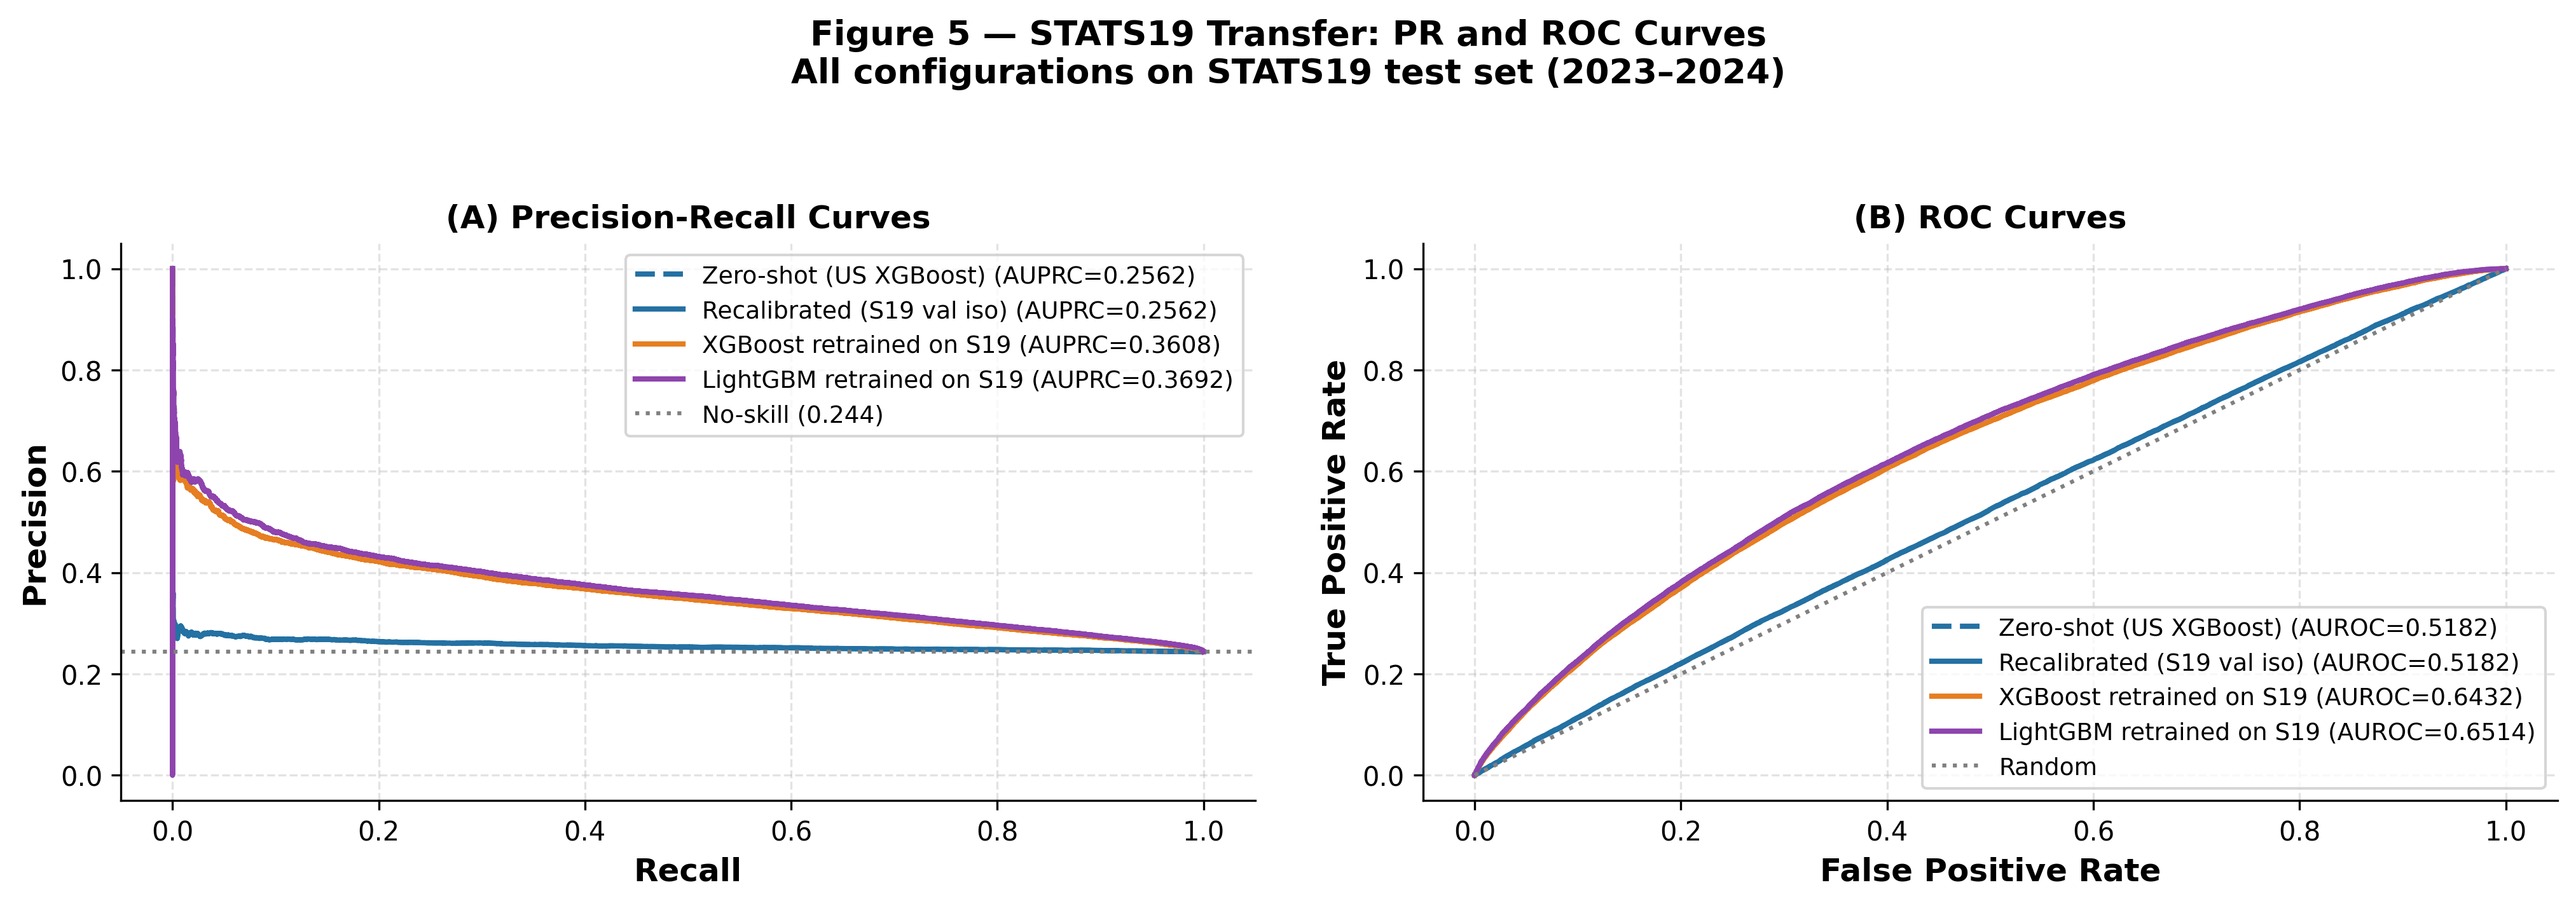

  fig5 saved ✓


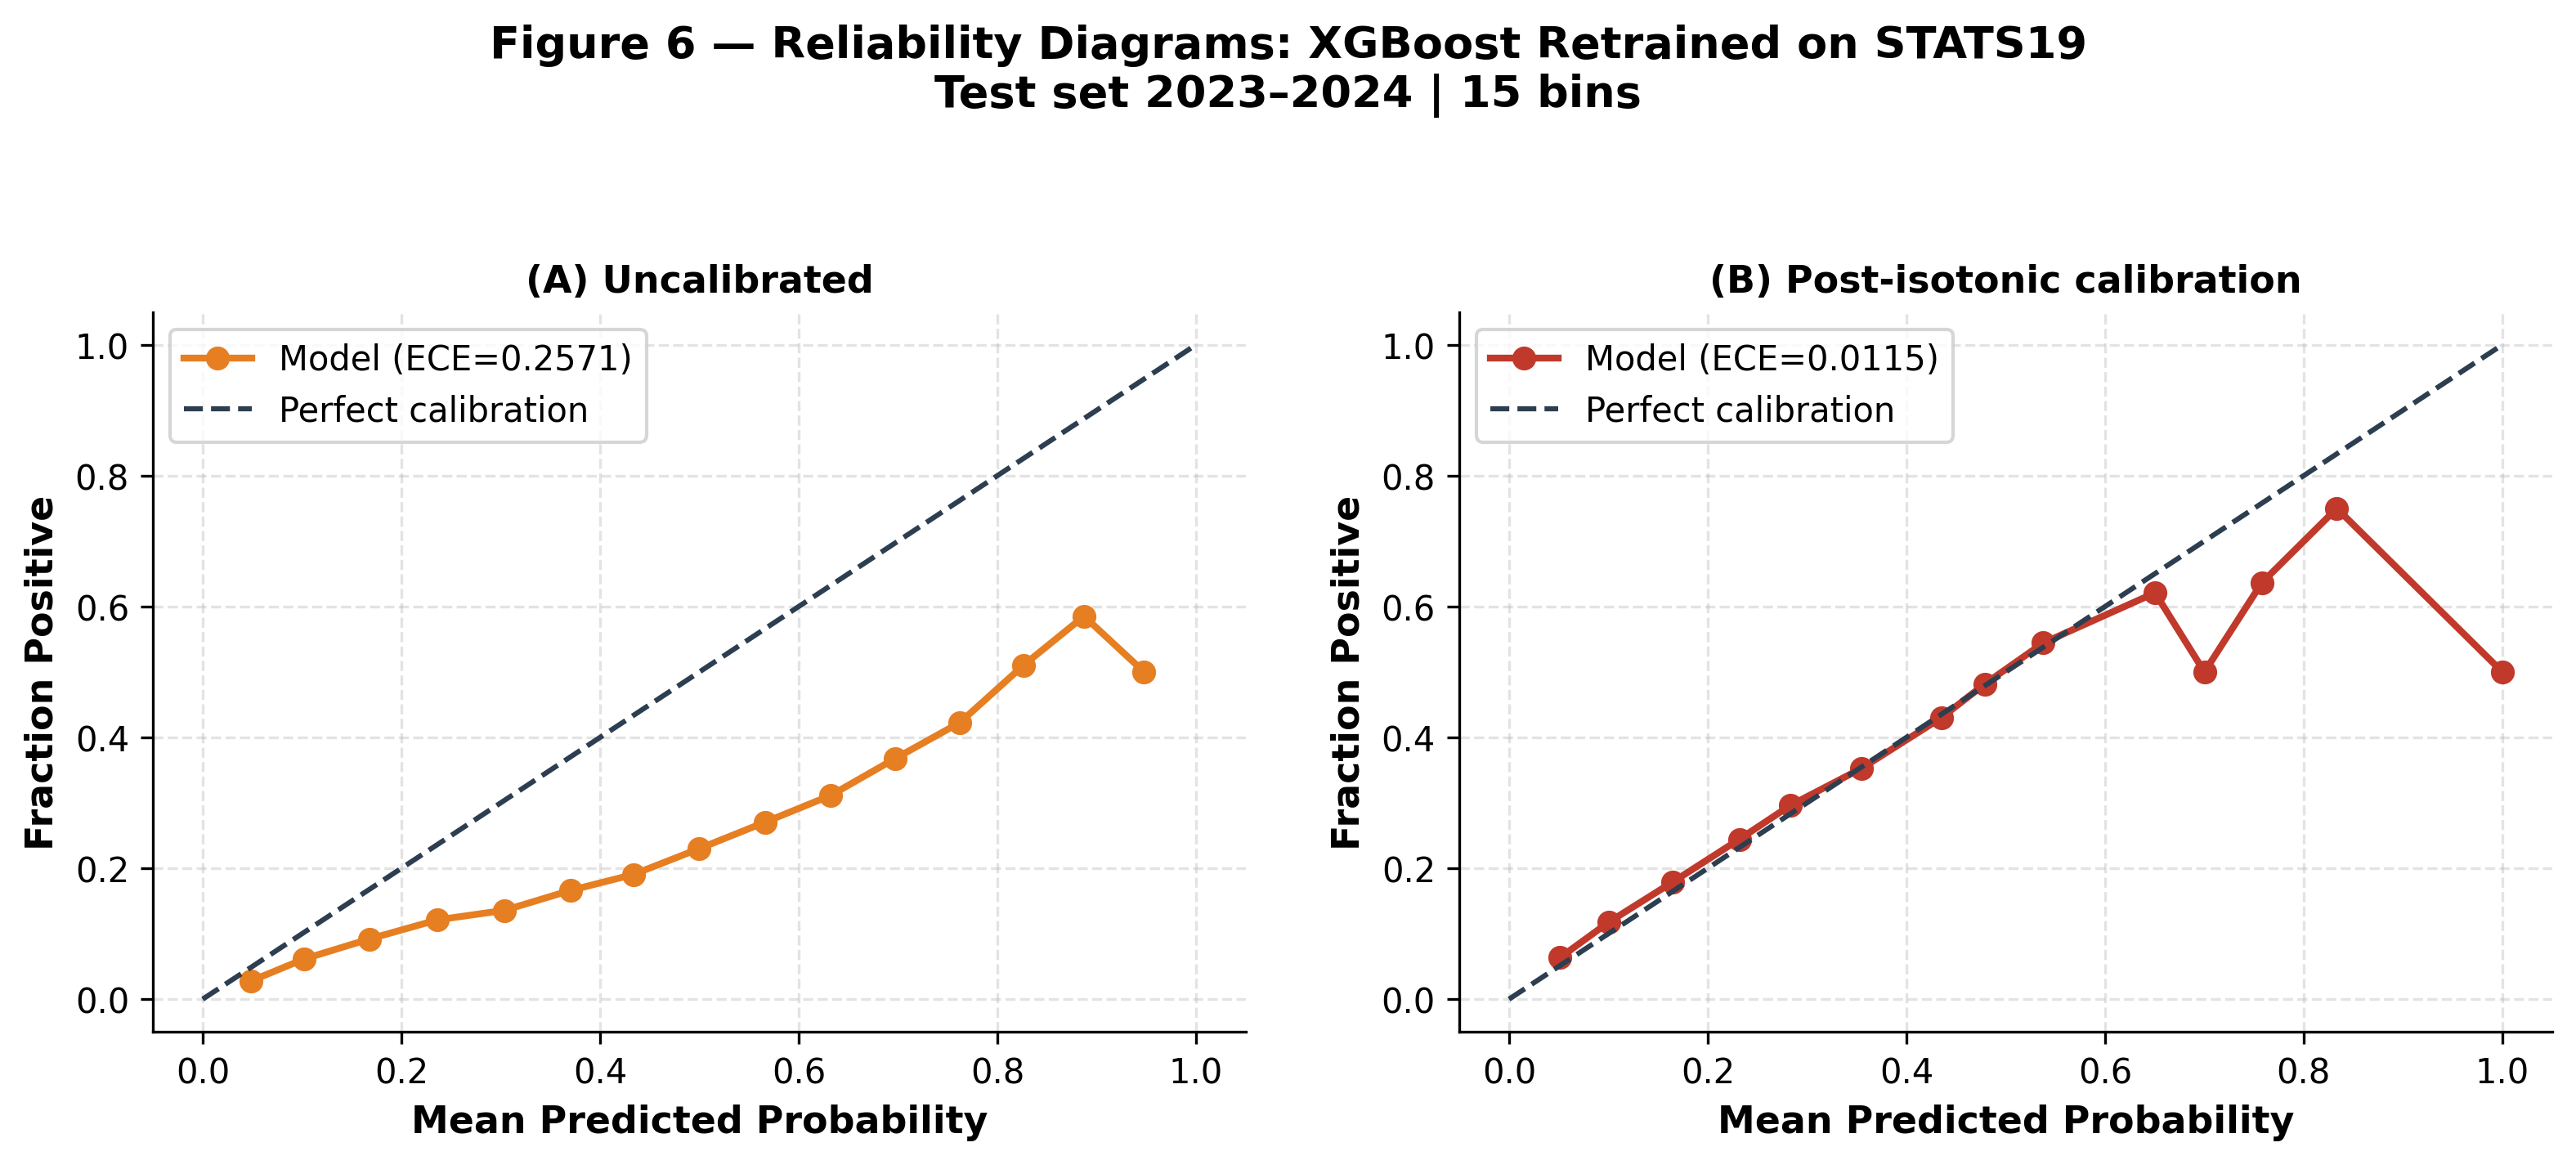

  fig6 saved ✓


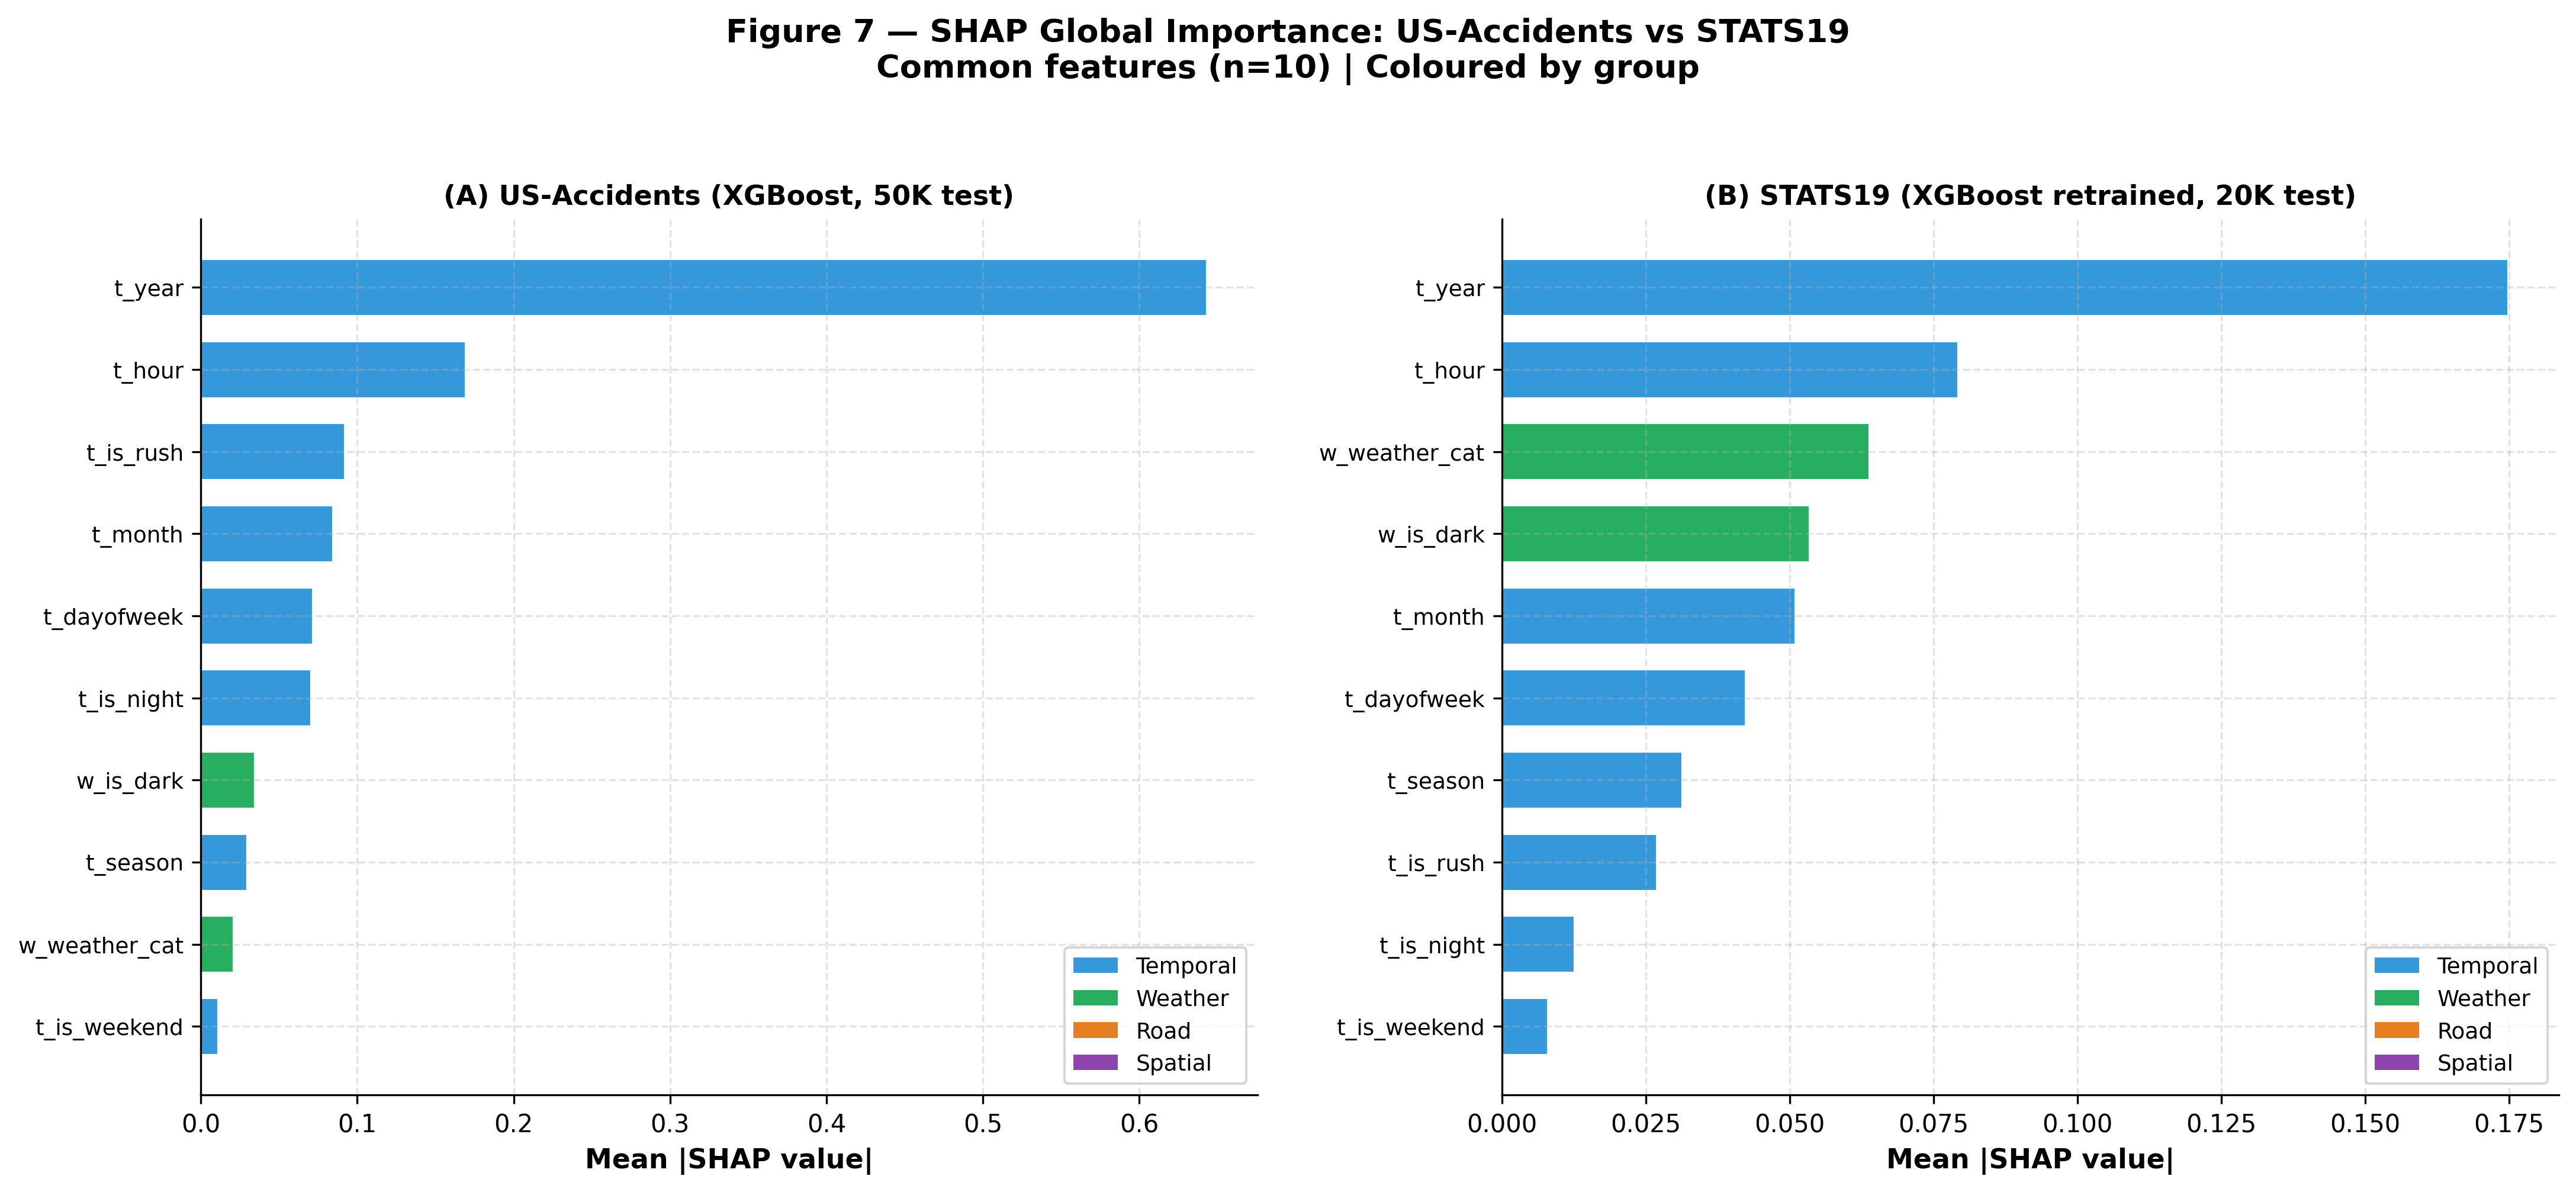

  fig7 saved ✓
Figures complete ✓


In [14]:
print('Step 10 — Generating figures ...')

# ── Figure 5: PR + ROC curves for all 4 S19 configurations ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5 — STATS19 Transfer: PR and ROC Curves\n'
             'All configurations on STATS19 test set (2023–2024)',
             fontsize=13, fontweight='bold')

styles = [
    (PALETTE['us'],   '--', 'o', 'Zero-shot (US XGBoost)'),
    (PALETTE['us'],   '-',  's', 'Recalibrated (S19 val iso)'),
    (PALETTE['xgb'],  '-',  '^', 'XGBoost retrained on S19'),
    (PALETTE['lgbm'], '-',  'D', 'LightGBM retrained on S19'),
]

ax = axes[0]
for r, (c, ls, mk, lbl) in zip(results, styles):
    prec, rec, _ = precision_recall_curve(y_s19_te, r['p_uncal'])
    ax.plot(rec, prec, color=c, ls=ls, lw=2,
            label=f'{lbl} (AUPRC={r["auprc"]:.4f})')
ax.axhline(y_s19_te.mean(), color='grey', ls=':', lw=1.5, label=f'No-skill ({y_s19_te.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('(A) Precision-Recall Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
for r, (c, ls, mk, lbl) in zip(results, styles):
    fpr, tpr, _ = roc_curve(y_s19_te, r['p_uncal'])
    ax.plot(fpr, tpr, color=c, ls=ls, lw=2,
            label=f'{lbl} (AUROC={r["auroc"]:.4f})')
ax.plot([0,1],[0,1], color='grey', ls=':', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('(B) ROC Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout(pad=2.5)
fig.savefig(FIGS_DIR / 'fig5_s19_pr_roc.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('  fig5 saved ✓')

# ── Figure 6: Reliability diagrams — retrained XGBoost before/after cal ───────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Figure 6 — Reliability Diagrams: XGBoost Retrained on STATS19\n'
             'Test set 2023–2024 | 15 bins',
             fontsize=13, fontweight='bold')

for ax, (p_plot, title_tag, col) in zip(axes, [
    (p_xgb_s19_test, 'Uncalibrated', PALETTE['uncal']),
    (p_xgb_s19_cal,  'Post-isotonic calibration', PALETTE['cal']),
]):
    frac_pos, mean_pred = calibration_curve(y_s19_te, p_plot, n_bins=ECE_BINS)
    ec = ece(y_s19_te, p_plot)
    ax.plot(mean_pred, frac_pos, 'o-', color=col, lw=2, ms=6,
            label=f'Model (ECE={ec:.4f})')
    ax.plot([0,1],[0,1], '--', color=PALETTE['perfect'], lw=1.5, label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraction Positive', fontsize=11, fontweight='bold')
    ax.set_title(f'({"A" if title_tag=="Uncalibrated" else "B"}) {title_tag}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout(pad=2.5)
fig.savefig(FIGS_DIR / 'fig6_s19_reliability.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('  fig6 saved ✓')

# ── Figure 7: SHAP importance comparison US vs S19 (common features) ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Figure 7 — SHAP Global Importance: US-Accidents vs STATS19\n'
             f'Common features (n={len(common_feats_aligned)}) | Coloured by group',
             fontsize=13, fontweight='bold')

for ax, (vals, title, model_tag) in zip(axes, [
    (us_vals,  'US-Accidents (XGBoost, 50K test)', 'US'),
    (s19_vals, 'STATS19 (XGBoost retrained, 20K test)', 'S19'),
]):
    order   = np.argsort(vals)[::-1]
    feats_o = [common_feats_aligned[i] for i in order]
    vals_o  = vals[order]
    colors  = [GRP_COLORS[GROUP_MAP[f]] for f in feats_o]
    y_pos   = np.arange(len(feats_o))
    ax.barh(y_pos, vals_o[::-1], color=colors[::-1], edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feats_o[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11, fontweight='bold')
    ax.set_title(f'({"A" if model_tag=="US" else "B"}) {title}', fontsize=11, fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(fc=c,label=g) for g,c in GRP_COLORS.items()],
              loc='lower right', fontsize=9)

plt.tight_layout(pad=2.5)
fig.savefig(FIGS_DIR / 'fig7_shap_us_vs_s19.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('  fig7 saved ✓')
print('Figures complete ✓')

---
## Step 10b — Figure S6: Three-Tier Transfer Framework Diagram (Fix 4)
Generate the schematic flowchart for the three-tier cross-dataset transfer framework
(zero-shot → recalibration-only → full retrain) with annotated metrics from Table 7.
This replaces the placeholder in Appendix E of v22.  
**Save at ≥300 DPI to SAE-XCrash/figures/wp5/figure_s6_transfer_framework.png**

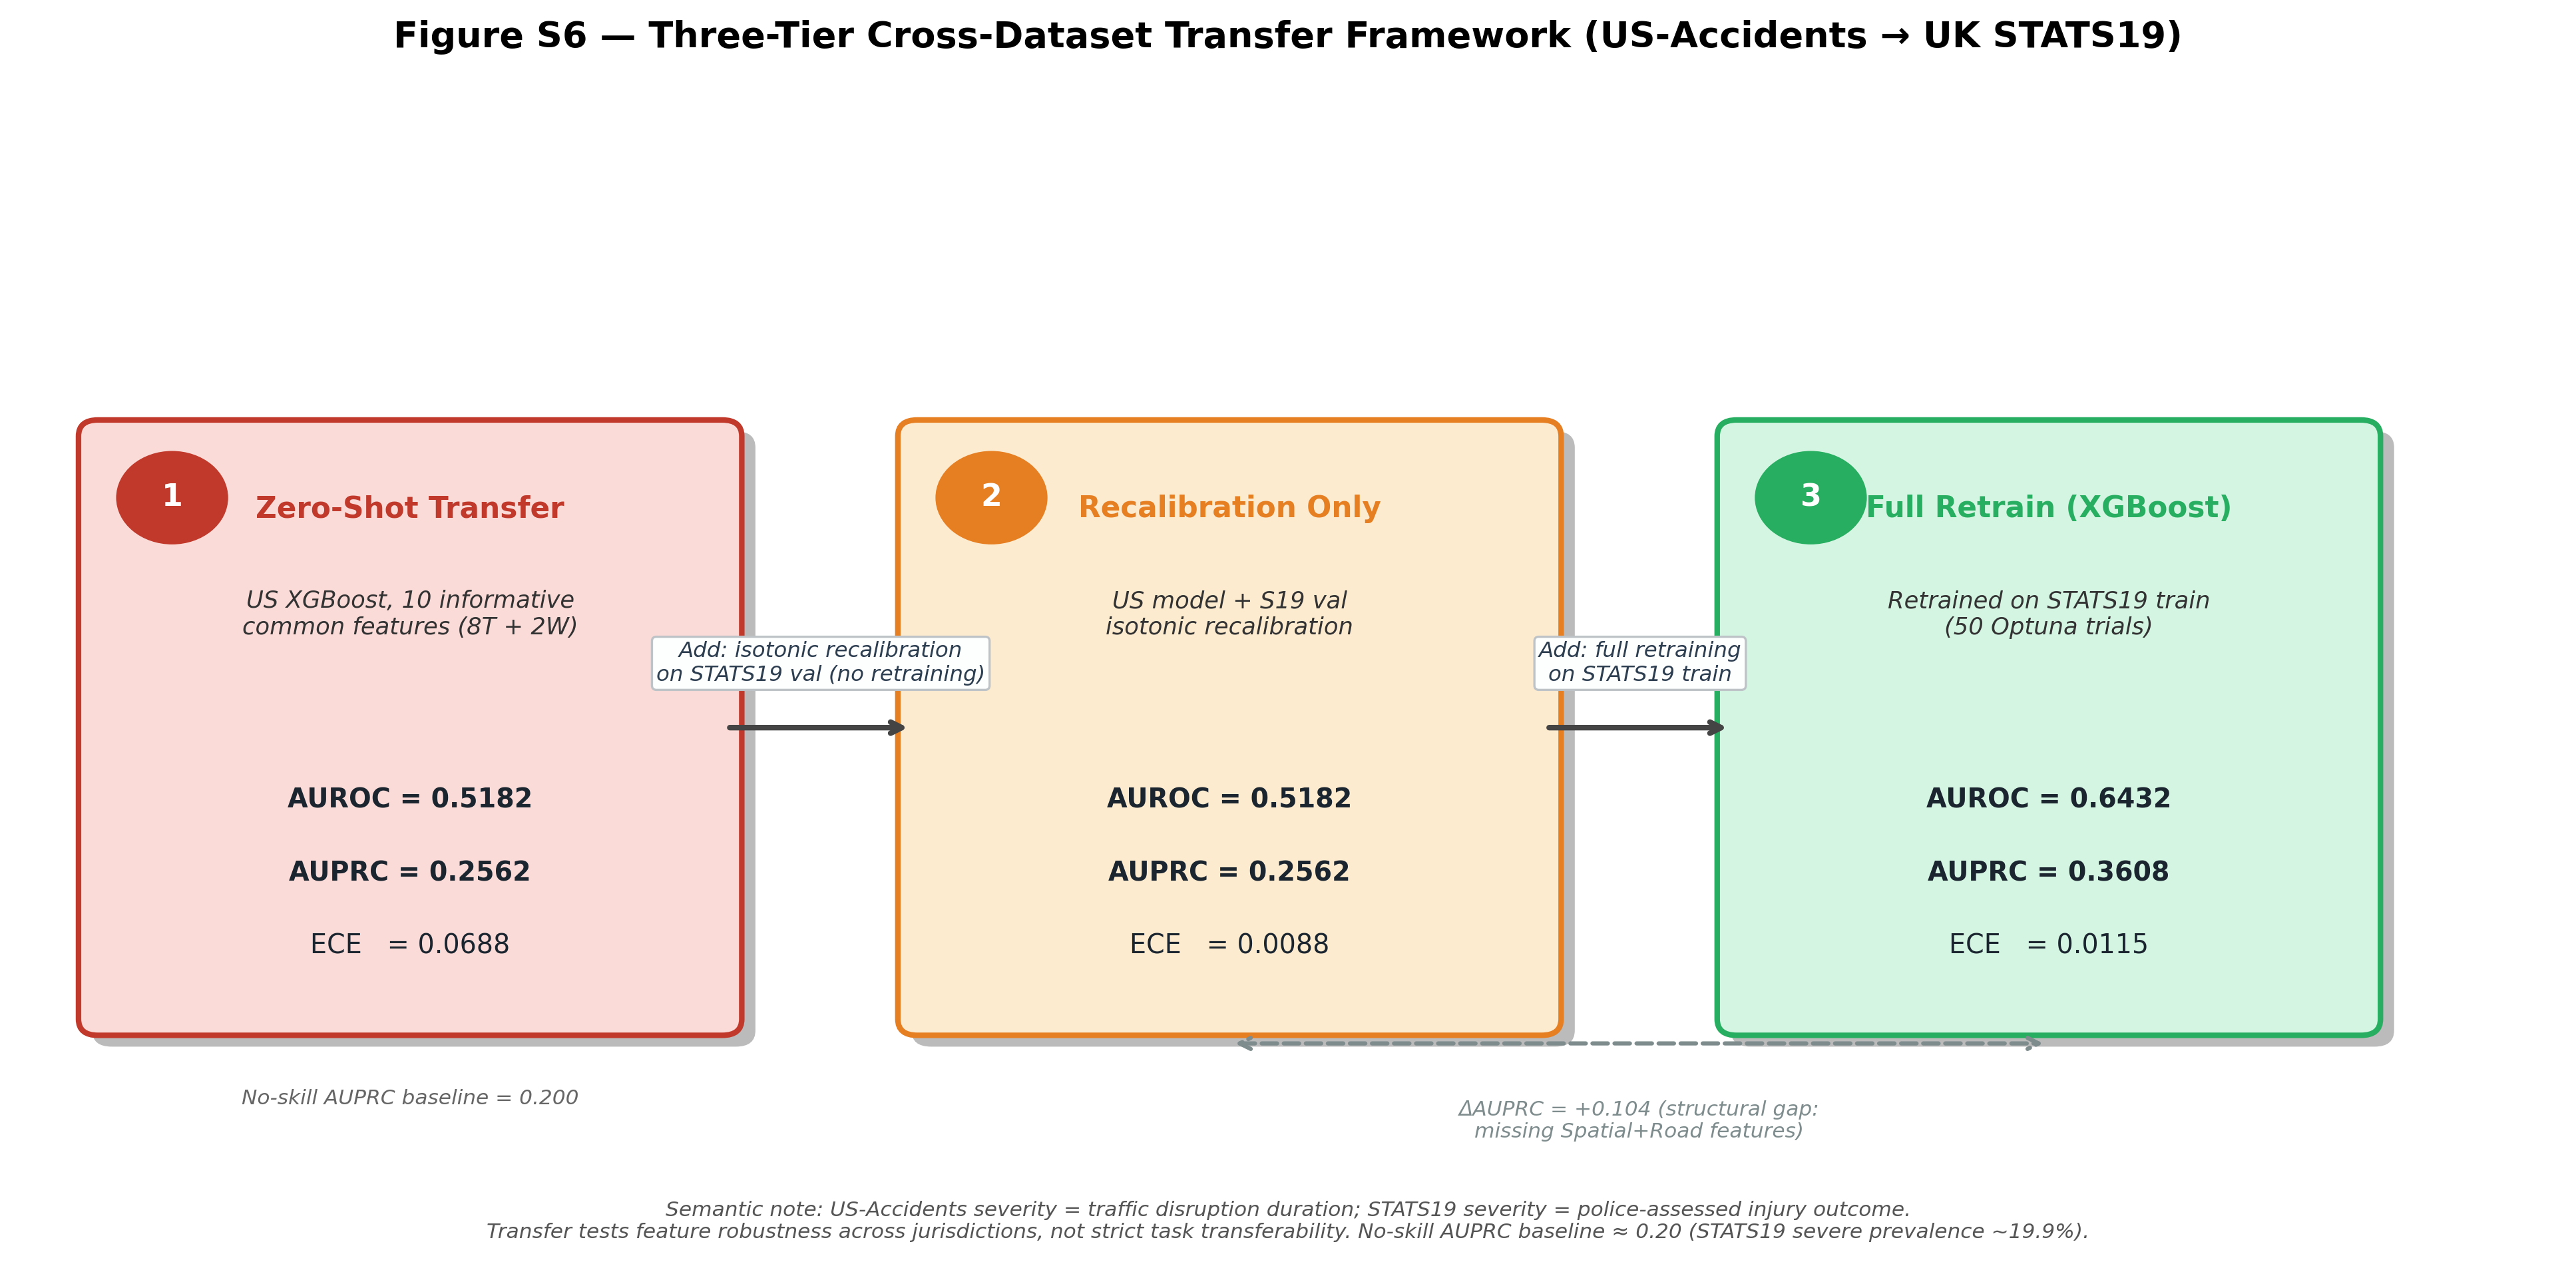

Saved: /content/drive/My Drive/SAE-XCrash/figures/wp5_v2/figure_s6_transfer_framework.png ✓

Insert figure_s6_transfer_framework.png into paper v22 Appendix E, replacing the existing placeholder image.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure S6 — Three-Tier Transfer Framework Schematic
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

# ── Data from Table 7 ────────────────────────────────────────────────────────
TIERS = [
    dict(
        label='Zero-Shot Transfer',
        sublabel='US XGBoost, 10 informative\ncommon features (8T + 2W)',
        action=None,
        auroc=0.5182, auprc=0.2562, ece=0.0688,
        color='#C0392B', light='#FADBD8',
    ),
    dict(
        label='Recalibration Only',
        sublabel='US model + S19 val\nisotonic recalibration',
        action='Add: isotonic recalibration\non STATS19 val (no retraining)',
        auroc=0.5182, auprc=0.2562, ece=0.0088,
        color='#E67E22', light='#FDEBD0',
    ),
    dict(
        label='Full Retrain (XGBoost)',
        sublabel='Retrained on STATS19 train\n(50 Optuna trials)',
        action='Add: full retraining\non STATS19 train',
        auroc=0.6432, auprc=0.3608, ece=0.0115,
        color='#27AE60', light='#D5F5E3',
    ),
]

fig_w, fig_h = 13, 7
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis('off')

fig.suptitle(
    'Figure S6 — Three-Tier Cross-Dataset Transfer Framework (US-Accidents → UK STATS19)',
    fontsize=13, fontweight='bold', y=0.97
)

BOX_W, BOX_H = 3.2, 3.6
BOX_TOPS     = [1.5, 1.5, 1.5]
BOX_LEFTS    = [0.4, 4.6, 8.8]

for i, (tier, bl, bt) in enumerate(zip(TIERS, BOX_LEFTS, BOX_TOPS)):
    # Box shadow
    shadow = mpatches.FancyBboxPatch(
        (bl + 0.07, bt - 0.07), BOX_W, BOX_H,
        boxstyle='round,pad=0.1', linewidth=0,
        facecolor='#BBBBBB', zorder=1
    )
    ax.add_patch(shadow)
    # Main box
    box = mpatches.FancyBboxPatch(
        (bl, bt), BOX_W, BOX_H,
        boxstyle='round,pad=0.1', linewidth=2,
        edgecolor=tier['color'], facecolor=tier['light'], zorder=2
    )
    ax.add_patch(box)

    # Tier number badge
    badge = plt.Circle((bl + 0.38, bt + BOX_H - 0.38), 0.28,
                        color=tier['color'], zorder=3)
    ax.add_patch(badge)
    ax.text(bl + 0.38, bt + BOX_H - 0.38, str(i + 1),
            ha='center', va='center', fontsize=11,
            fontweight='bold', color='white', zorder=4)

    # Title
    ax.text(bl + BOX_W / 2, bt + BOX_H - 0.45,
            tier['label'], ha='center', va='center',
            fontsize=10.5, fontweight='bold', color=tier['color'], zorder=3)

    # Sublabel
    ax.text(bl + BOX_W / 2, bt + BOX_H - 0.95,
            tier['sublabel'], ha='center', va='top',
            fontsize=8.5, color='#333333', style='italic', zorder=3)

    # Metrics
    metrics_y  = bt + 1.35
    ax.text(bl + BOX_W / 2, metrics_y,
            f'AUROC = {tier["auroc"]:.4f}', ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='#1A252F', zorder=3)
    ax.text(bl + BOX_W / 2, metrics_y - 0.45,
            f'AUPRC = {tier["auprc"]:.4f}', ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='#1A252F', zorder=3)
    ax.text(bl + BOX_W / 2, metrics_y - 0.90,
            f'ECE   = {tier["ece"]:.4f}', ha='center', va='center',
            fontsize=9.5, color='#1A252F', zorder=3)

    # No-skill reference line annotation (only on box 1)
    if i == 0:
        ax.text(bl + BOX_W / 2, bt - 0.55,
                'No-skill AUPRC baseline = 0.200', ha='center', va='bottom',
                fontsize=7.5, color='#666666', style='italic', zorder=3)

    # Arrow + action label between tiers
    if i < 2:
        ax_x = BOX_LEFTS[i] + BOX_W + 0.01
        ar_y = bt + BOX_H / 2
        ax.annotate('',
            xy=(BOX_LEFTS[i+1] - 0.02, ar_y),
            xytext=(ax_x, ar_y),
            arrowprops=dict(arrowstyle='->', color='#444444', lw=2.0),
            zorder=5
        )
        mid_x = (ax_x + BOX_LEFTS[i+1]) / 2
        ax.text(mid_x, ar_y + 0.26, TIERS[i+1]['action'],
                ha='center', va='bottom', fontsize=7.8,
                color='#2C3E50', style='italic',
                bbox=dict(boxstyle='round,pad=0.2', fc='#FDFEFE',
                          ec='#BDC3C7', lw=0.8),
                zorder=5)

# Delta annotation between tiers
for (i1, i2, note_text) in [
    (1, 2, 'ΔAUPRC = +0.104 (structural gap:\nmissing Spatial+Road features)'),
]:
    x1 = BOX_LEFTS[i1] + BOX_W / 2
    x2 = BOX_LEFTS[i2] + BOX_W / 2
    ax.annotate('',
        xy=(x2, BOX_TOPS[i2] - 0.15),
        xytext=(x1, BOX_TOPS[i1] - 0.15),
        arrowprops=dict(arrowstyle='<->', color='#7F8C8D', lw=1.5, linestyle='dashed'),
        zorder=4
    )
    ax.text((x1+x2)/2, BOX_TOPS[i1] - 0.50, note_text,
            ha='center', va='top', fontsize=7.5, color='#7F8C8D',
            style='italic', zorder=4)

# Footnote
ax.text(6.5, 0.25,
    'Semantic note: US-Accidents severity = traffic disruption duration; '
    'STATS19 severity = police-assessed injury outcome.\n'
    'Transfer tests feature robustness across jurisdictions, not strict task transferability. '
    'No-skill AUPRC baseline ≈ 0.20 (STATS19 severe prevalence ~19.9%).',
    ha='center', va='center', fontsize=7.5, color='#555555',
    style='italic', wrap=True, zorder=3
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])

fig_path = FIGS_DIR / 'figure_s6_transfer_framework.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path} ✓')
print('\nInsert figure_s6_transfer_framework.png into paper v22 Appendix E,'
      ' replacing the existing placeholder image.')


---
## Step 11 — Save All Results & WP5 Summary

In [16]:
# ── Save score files ──────────────────────────────────────────────────────────
scores_df = pd.DataFrame({
    'label'            : y_s19_te,
    'score_zs_uncal'   : p_zs_test,
    'score_zs_uscal'   : p_zs_test_cal,
    'score_zs_recal'   : p_recal_test,
    'score_xgb_s19_uncal': p_xgb_s19_test,
    'score_xgb_s19_cal': p_xgb_s19_cal,
    'score_lgb_s19_uncal': p_lgb_s19_test,
    'score_lgb_s19_cal': p_lgb_s19_cal,
})
scores_df.to_parquet(SCORES_DIR / 's19_test_scores.parquet', index=False)

# ── Save Table 6 ──────────────────────────────────────────────────────────────
table6_rows = []
for r in results:
    table6_rows.append({
        'Configuration' : r['config'],
        'AUROC'         : round(r['auroc'], 4),
        'AUPRC'         : round(r['auprc'], 4),
        'AUPRC_CI_lo'   : round(r['auprc_ci_lo'], 4),
        'AUPRC_CI_hi'   : round(r['auprc_ci_hi'], 4),
        'ECE_uncal'     : round(r['ece_uncal'], 4),
        'ECE_cal'       : round(r['ece_cal'], 4),
        'Brier'         : round(r['brier'], 4),
    })
table6_df = pd.DataFrame(table6_rows)
table6_df.to_csv(LOGS_DIR / 'wp5_table6.csv', index=False)

# ── Save Table 7 ──────────────────────────────────────────────────────────────
table7_df.to_csv(LOGS_DIR / 'wp5_table7_spearman.csv', index=False)
shap_s19_df.to_csv(LOGS_DIR / 'wp5_shap_s19_importance.csv', index=False)
shift_df.to_csv(LOGS_DIR / 'wp5_distributional_shift.csv', index=False)

# ── Save full WP5 log ─────────────────────────────────────────────────────────
wp5_log = {
    'generated_at'    : str(datetime.now()),
    'n_common_features': len(FEAT_COMMON),
    'common_features' : FEAT_COMMON,
    'table6'          : table6_rows,
    'table7'          : table7_df.to_dict(orient='records'),
    'distributional_shift': shift_df.to_dict(orient='records'),
    'spearman_overall': {'rho': round(rho_all,4), 'p': round(p_all,4)},
}
with open(LOGS_DIR / 'wp5_transfer_log.json', 'w') as f:
    json.dump(wp5_log, f, indent=2)

# ── Console report ────────────────────────────────────────────────────────────
print('=' * 70)
print('  SAE-XCrash  |  WP5 COMPLETE — NB05 STATS19 Transfer')
print('=' * 70)

print('\n📊 TABLE 6 — Cross-Dataset Transfer (STATS19 test 2023–2024)')
print(f'{"Configuration":<42} {"AUROC":>6} {"AUPRC":>7} {"95% CI":>16} {"ECE_u":>6} {"ECE_c":>6} {"Brier":>6}')
print('-' * 90)
for r in table6_rows:
    ci_str = f'[{r["AUPRC_CI_lo"]:.4f}–{r["AUPRC_CI_hi"]:.4f}]'
    print(f'{r["Configuration"]:<42} {r["AUROC"]:>6.4f} {r["AUPRC"]:>7.4f} '
          f'{ci_str:>16} {r["ECE_uncal"]:>6.4f} {r["ECE_cal"]:>6.4f} {r["Brier"]:>6.4f}')

print('\n📊 TABLE 7 — Spearman SHAP Rank Correlation (US vs S19, common features)')
print(table7_df.to_string(index=False))

print('\n📊 DISTRIBUTIONAL SHIFT (US train → S19 train, JSD per group)')
print(shift_df.to_string(index=False))

print('\n📁 OUTPUT FILES')
all_out = (list((FIGS_DIR).glob('*.png')) +
           [LOGS_DIR / f for f in [
               'wp5_table6.csv','wp5_table7_spearman.csv',
               'wp5_shap_s19_importance.csv','wp5_distributional_shift.csv',
               'wp5_transfer_log.json'
           ]] +
           [SCORES_DIR / 's19_test_scores.parquet',
            MODELS_DIR / 'xgb_s19.json', MODELS_DIR / 'lgbm_s19.txt'])
for p in sorted(all_out):
    p = Path(p)
    if p.exists():
        sz  = p.stat().st_size
        tag = f'{sz/1e6:.1f} MB' if sz > 1e6 else f'{sz/1e3:.0f} KB'
        print(f'  {tag:8s}  {p}')

print('\n➡  NEXT: WP6 — Paper finalisation')
print('   Fill Tables 6–7 with above values.')
print('   Update §7.3 (cross-dataset) with Spearman rho and JSD findings.')
print('   Update Abstract [TBF] STATS19 AUPRC placeholders.')
print('=' * 70)

  SAE-XCrash  |  WP5 COMPLETE — NB05 STATS19 Transfer

📊 TABLE 6 — Cross-Dataset Transfer (STATS19 test 2023–2024)
Configuration                               AUROC   AUPRC           95% CI  ECE_u  ECE_c  Brier
------------------------------------------------------------------------------------------
XGBoost zero-shot (US model)               0.5182  0.2562  [0.2536–0.2590] 0.0688 0.2278 0.2362
XGBoost recalibrated (S19 val iso)         0.5182  0.2562  [0.2536–0.2590] 0.0688 0.0088 0.1843
XGBoost retrained on S19                   0.6432  0.3608  [0.3568–0.3647] 0.2571 0.0115 0.1756
LightGBM retrained on S19                  0.6514  0.3692  [0.3651–0.3731] 0.2688 0.0099 0.1745

📊 TABLE 7 — Spearman SHAP Rank Correlation (US vs S19, common features)
       Feature Group  n_common  Spearman_rho  p_value
            Temporal         8        0.8095   0.0149
             Weather         2       -1.0000      NaN
                Road         0           NaN      NaN
             Spatial     

In [17]:
print(study_xgb_s19.best_params)

{'max_depth': 7, 'learning_rate': 0.06894220724876202, 'subsample': 0.9041811650219274, 'colsample_bytree': 0.6847502782887033, 'min_child_weight': 16, 'reg_alpha': 0.0949834101810708, 'reg_lambda': 2.9718645216107186e-07, 'gamma': 0.7579147950107037, 'n_estimators': 1040}
